In [1]:
import sys
import numpy as np
import anndata as ad
import polars as pl

import src as scit
import matplotlib.pyplot as plt
import cv2

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cttag_shape0 = 26324

In [3]:
mt_muscle_meth = pl.read_csv('private/data/wt_mt_meth_change.csv').filter((pl.col('base_mean') > 0.5) & (pl.col('group') == 'Muscle'))
mt_muscle_acet = pl.read_csv('private/data/wt_mt_acet_change.csv').filter((pl.col('base_mean') > 0.8) & (pl.col('group') == 'Muscle'))

In [4]:
ac_breadth = pl.read_csv('private/data/acet_breadth.csv').filter(pl.col('breadth')>0.01*cttag_shape0)
#me_breadth = pl.read_csv('private/data/meth_breadth.csv')

In [7]:
ref = scit.ld.gtf('../data/dmel-all-r6.56.gtf', extra_key='gene_id')

obodag = scit.ld.obodag('../data/dm-stage6.obo', namespaces = { 'insitu': 'MF' })
ns2assoc = scit.ld.gaf('../data/stage6_gene2go.gaf', obodag, name_column=2)

../data/dm-stage6.obo: fmt(1.2) rel(2024-01-17) 139 Terms


In [24]:
#meth_pop = mt_muscle_meth['name'].unique().to_numpy()
#acet_pop = mt_muscle_acet['name'].unique().to_numpy()
#pop = rna_acme_corr['var_name'].unique().to_numpy()
pop = ac_breadth['name'].unique().to_numpy()

res = scit.tl.goea(
    obodag,
    ns2assoc,
    scit.tl.symbol2id(ref, pop),
    scit.tl.symbol2id(ref, ac_breadth.filter(pl.col('breadth') < 0.1*cttag_shape0)['name'].to_numpy()),
    #scit.tl.symbol2id(ref, rna_acme_corr.filter(pl.col('res') < 0.3).filter(pl.col('res_meth') > 0.2)['var_name'].to_numpy()),
    # mt_muscle_acet.filter((pl.col('pval')<0.01) & (pl.col('score') < -0.2))['name'].to_numpy()),
    propagate_counts=True,
    alpha=0.1
)


Load BP Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 29%  3,020 of 10,494 population items found in association

Load CC Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 29%  3,020 of 10,494 population items found in association

Load MF Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 29%  3,020 of 10,494 population items found in association

Runing BP Ontology Analysis: current study set of 5853 IDs.
 27%  1,585 of  5,853 study items found in association
100%  5,853 of  5,853 study items found in population(10494)
Calculating 0 uncorrected p-values using fisher_scipy_stats

Runing CC Ontology Analysis: current study set of 5853 IDs.
 27%  1,585 of  5,853 study items found in association
100%  5,853 of  5,853 study items found in population(10494)
Calculating 0 uncorrected p-values using fisher_scipy_stats

Runing MF Ontology Analysis: current study set of 5853 IDs.
 27%  1,585 of  5,853 study items found in association
100% 

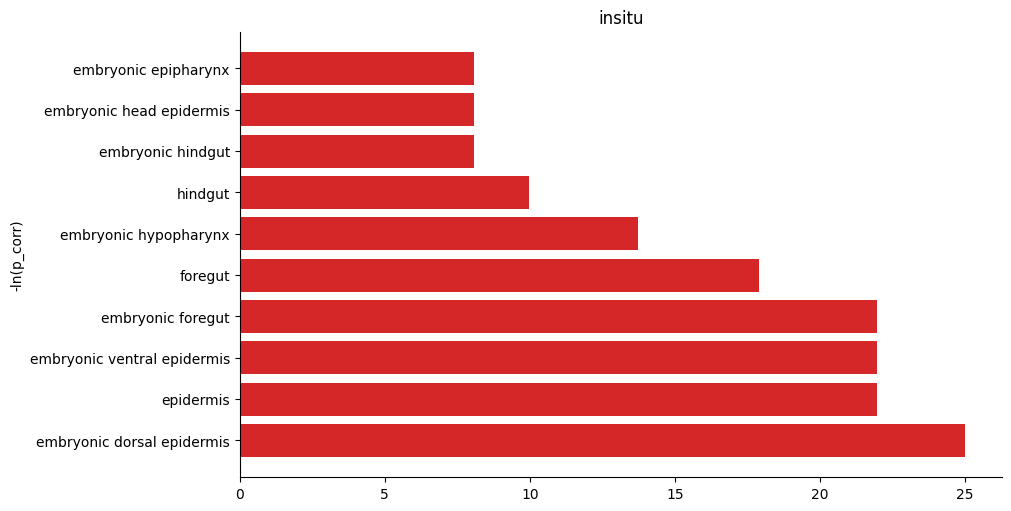

In [25]:
scit.pl.goea(res, 'simple')

In [ ]:
fs = scit.pl.goea(res, 'simple', show=False, n_top=40)
m = scit.adv.ImageToolsCV2.join_figures(fs, crop=False, direction='vertical') 

#cv2.imwrite(f'private/newest/goterm/broad_acetylation.png', m)
plt.close('all')